<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Clustering II. Sesión Sincrónica.

Tanto Clustering como PCA y SVD buscan simplificar los datos de forma no supervisada, pero sus mecanismos son diferentes:

- PCA y SVD buscan una representación de baja dimensión que explique una buena fracción de la varianza;

- Clustering busca subgrupos homogéneos entre las observaciones.

El objetivo de este cuaderno es introducir los algoritmos que serán estudiados en la semana 4: **clustering jerárquico** y **DBSCAN**.

**NO** es necesario editar el archivo o hacer una entrega. Los ejemplos contienen celdas con código ejecutable (`en gris`), que podrá modificar libremente. Esta puede ser una buena forma de aprender nuevas funcionalidades del *cuaderno*, o experimentar variaciones en los códigos de ejemplo.

# 1. Repaso

La semana pasada K-medias funcionó bien. Vale la pena mirar de qué se dependía:

1. **Le dijimos cuántos grupos buscar.** $K$ es un argumento, no un resultado.
2. **Busca centros y asigna al más cercano.** Eso dibuja grupos con forma de esfera, todas
   más o menos del mismo tamaño.
3. **Todo punto termina en algún grupo.** No existe la respuesta "ninguno".

Los tres son supuestos, veamos qué pasa cuando no se cumplen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

SEMILLA = 1234
rng = np.random.RandomState(SEMILLA)

# tres situaciones donde los supuestos de K-medias no se cumplen
lunas, _ = make_moons(n_samples=300, noise=0.06, random_state=SEMILLA)

denso, _  = make_blobs(n_samples=220, centers=[[0, 0]], cluster_std=0.25, random_state=SEMILLA)
disperso, _ = make_blobs(n_samples=70, centers=[[5, 5]], cluster_std=1.60, random_state=SEMILLA)
densidades = np.vstack([denso, disperso])

nucleos, _ = make_blobs(n_samples=200, centers=[[0, 0], [4, 0]], cluster_std=0.55, random_state=SEMILLA)
atipicos = np.vstack([nucleos, rng.normal([2.0, 11.0], 0.6, size=(8, 2))])

SITUACIONES = [('Formas no globulares', lunas,      2, 0.20,  5),
               ('Densidades distintas', densidades, 2, 0.30,  6),
               ('Valores atipicos',     atipicos,   2, 0.70, 10)]

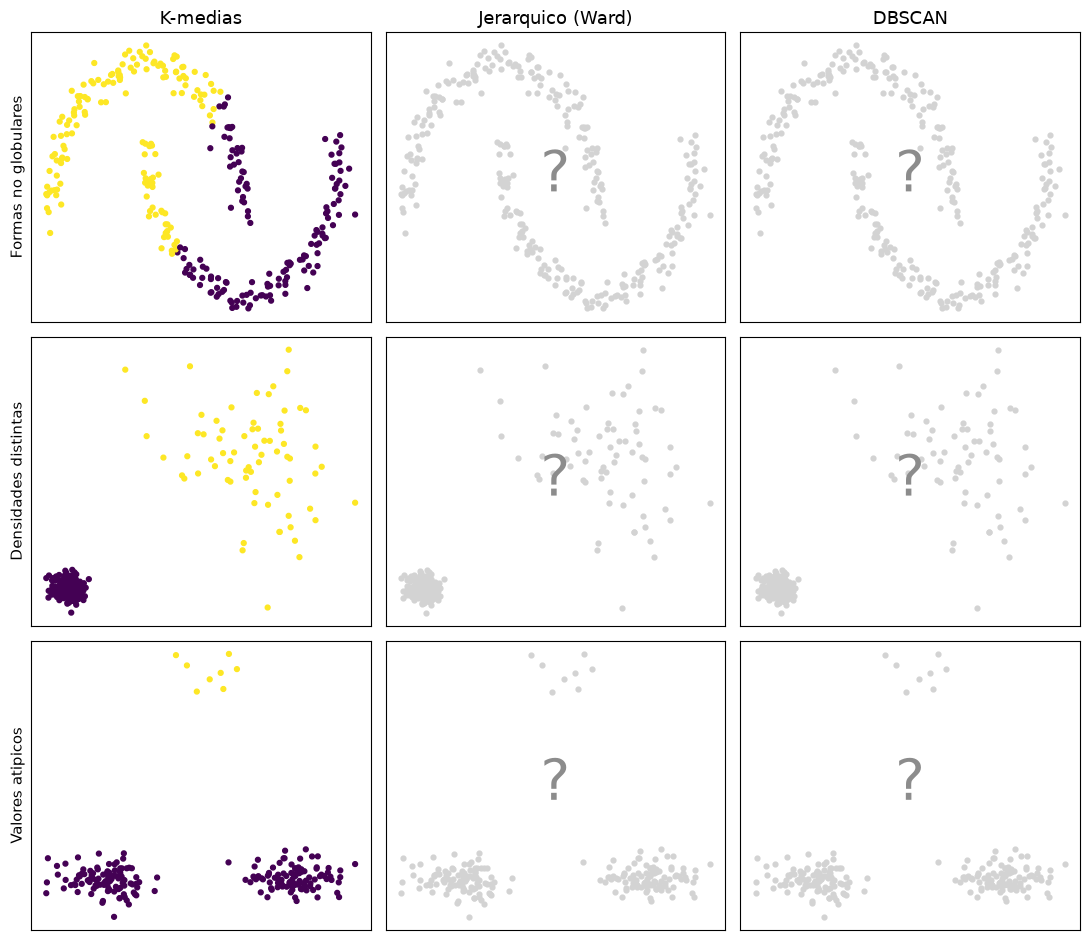

In [2]:
def grilla(situaciones, columnas_visibles=1):
    '''Grilla situacion x algoritmo. Las columnas todavia no vistas salen en gris.'''
    fig, axes = plt.subplots(3, 3, figsize=(11, 9.5))
    for i, (nombre, X, k, eps, min_samples) in enumerate(situaciones):
        etiquetas = [
            ('K-medias',          KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit_predict(X)),
            ('Jerarquico (Ward)', AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)),
            ('DBSCAN',            DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)),
        ]
        for j, (titulo, et) in enumerate(etiquetas):
            ax = axes[i, j]
            if j < columnas_visibles:
                ruido = et == -1
                ax.scatter(X[~ruido, 0], X[~ruido, 1], c=et[~ruido], cmap='viridis', s=12)
                if ruido.any():
                    ax.scatter(X[ruido, 0], X[ruido, 1], c='lightgray', s=14, marker='x')
            else:
                ax.scatter(X[:, 0], X[:, 1], c='lightgray', s=12)
                ax.text(0.5, 0.5, '?', transform=ax.transAxes, fontsize=40,
                        color='0.55', ha='center', va='center')
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0: ax.set_title(titulo, fontsize=13)
            if j == 0: ax.set_ylabel(nombre, fontsize=11)
    plt.tight_layout(); plt.show()

grilla(SITUACIONES, columnas_visibles=1)

Fíjense en la primera columna, que es la única que sabemos leer hasta ahora:

- **Medias lunas.** K-medias corta vertical por el medio. No puede hacer otra cosa:
  asigna al centro más cercano, y el centro de una luna cae dentro de la otra.
- **Densidades distintas.** Acá sí acierta. 
- **Valores atípicos.** Ocho puntos alejados **se llevan un centroide entero**, y los dos
  grupos de verdad quedan fundidos en uno solo. Ocho puntos sobre 208.

Las otras dos columnas son la sesión de hoy. 

## Los tres supuestos, y quién los suelta

| Supuesto de K-medias | Qué pasa cuando no se cumple | Quién lo suelta hoy |
|---|---|---|
| Hay que elegir $K$ **antes** | Se elige mal y no hay forma de darse cuenta | **Jerárquico**: deja elegirlo *después*, mirando la estructura |
| Los grupos son esferas de tamaño parecido | Parte las medias lunas por la mitad | **DBSCAN**: sigue la densidad, no la forma |
| Todo punto pertenece a algún grupo | Ocho atípicos se llevan un centroide | **DBSCAN**: puede contestar *ruido* |

Una aclaración sobre el primer punto: el
jerárquico **no** los libera de elegir $K$. Lo mueve del *antes* al *después* — a la
altura donde uno corta el árbol. Es la misma decisión con otra interfaz. El único que de
verdad infiere el número de grupos es DBSCAN.

# 2. La distacina siempre es clave

Los dos algoritmos de hoy necesitan la matriz completa $D_{n\times n}$,

La semana pasada usamos la **distancia euclidiana** y **estandarizamos** antes de
calcularla, porque si no las variables con más rango se "comen" el resultado. Eso sigue
valiendo.

Pero estandarizar sólo tiene sentido si las variables son numéricas. Y los datos con los
que vamos a trabajar hoy —clientes de un banco— tienen edad y saldo, sí, pero también
estado civil y nivel educativo. **¿Cuánto vale la diferencia entre "casado" y "soltero"?**

La distancia no es un detalle de implementación. Es la primera decisión del análisis, y  el resultado se apoya entero en ella.

# 3. Clustering jerárquico

En vez de repartir los puntos en $K$ grupos de una vez, el jerárquico construye **toda la
jerarquía**: arranca con cada observación sola, une las dos más parecidas, y repite hasta
que queda un solo grupo.

El resultado no es una partición, es un árbol: el **dendrograma**. La altura a la que dos
ramas se juntan es la distancia a la que se fusionaron.

Eso cambia el orden de las decisiones. No hay que comprometerse con $K$ para poder correr
el algoritmo; se corre una vez, se mira el árbol, y **ahí** se decide dónde cortarlo.

Hay dos versiones:

- **aglomerativo** (de abajo hacia arriba): el que acabo de describir, y el único que
  vamos a usar.
- **divisivo** (de arriba hacia abajo): arranca con todo junto y va partiendo. Es más
  caro y casi nadie lo usa; `scipy` ni siquiera lo implementa.

## 3.1. El enlace

Acá aparece algo que ningún otro algoritmo del curso necesita. Para unir dos
observaciones alcanza con la distancia entre ellas. Pero cuando hay un grupo de tres
puntos y otro de cinco, **¿cuál es la distancia entre los dos grupos?**

Esa regla se llama **enlace**, y hay que elegirla:

| Enlace | La distancia entre dos grupos es… | Qué produce |
|---|---|---|
| **Simple** | la del par **más cercano**: $\;d_{SL}(G,H)=\min_{i\in G,\,i'\in H} d_{ii'}$ | Grupos alargados; encadena |
| **Completo** | la del par **más lejano**: $\;d_{CL}(G,H)=\max_{i\in G,\,i'\in H} d_{ii'}$ | Grupos compactos y parejos |
| **Ward** | la que **menos aumenta** la suma de cuadrados interna | Grupos de tamaño similar |

También existen el promedio (*average*) y el de centroides, que hacen lo que su nombre
dice. No hay una guía en la literatura sobre cuál es el mejor: depende del problema y de
la disciplina. El de centroides es popular entre los genetistas, y Ward entre los
economistas.

> Es decir: el jerárquico necesita **dos** especificaciones, una distancia *y* un
> enlace. Todos los demás algoritmos que vemos en el curso necesitan sólo la distancia.

## 3.2. Un ejemplo a mano

Cinco observaciones, con las distancias ya calculadas:

|   | 1  | 2  | 3 | 4 | 5 |
|---|----|----|---|---|---|
| **1** | 0  |    |   |   |   |
| **2** | 9  | 0  |   |   |   |
| **3** | 3  | 7  | 0 |   |   |
| **4** | 6  | 5  | 9 | 0 |   |
| **5** | 11 | 10 | 2 | 8 | 0 |

**Con enlace simple.** El mínimo de la tabla es $d_{35}=2$: se unen 3 y 5. Ahora hay que
calcular la distancia del grupo $\{3,5\}$ contra el resto, y con enlace simple es el
**mínimo** de las dos:

$$d(\{3,5\},\,1)=\min(3,\,11)=3 \qquad d(\{3,5\},\,2)=\min(7,\,10)=7 \qquad d(\{3,5\},\,4)=\min(9,\,8)=8$$

Se repite: el nuevo mínimo es 3, así que entra el 1. Y así hasta el final.

<div style="max-width:420px">
<img src = "figs/single_link.png" />
</div>

El árbol con **enlace simple**. Se lee de abajo hacia arriba: 3 y 5 se juntan a altura 2,
el 1 se les suma a altura 3, y recién arriba entra el par 2–4.

Con **enlace completo** cambia una sola cosa: en vez del mínimo se toma el máximo.
$d(\{3,5\},1)=\max(3,11)=11$, y así. El resto del procedimiento es idéntico.

<div style="max-width:420px">
<img src = "figs/complete_link.png" />
</div>

Y el árbol es otro. **Mismos cinco puntos, mismas distancias, dos respuestas
distintas**: acá el 1 no se pega a $\{3,5\}$, se va con el 2 y el 4. Fíjense también en
la escala del eje: el enlace completo produce alturas mucho más grandes, porque siempre
mide contra el punto más lejano.

Por eso decía que el enlace no es un detalle de implementación.

## 3.3. Cortar el árbol

Un dendrograma no da grupos: da todos los agrupamientos posibles a la vez. Para quedarse
con uno hay que **cortar** a una altura, y cada corte devuelve un número de grupos
distinto. Ahí es donde reaparece la decisión de $K$ que el jerárquico había pospuesto.

En `scipy` se hace así:

```python
Z = linkage(D_condensada, method='average')
etiquetas = fcluster(Z, t=6, criterion='distance')   # cortar a la altura 6
etiquetas = fcluster(Z, t=4, criterion='maxclust')   # o pedir 4 grupos
```

> **Dos advertencias que les van a hacer falta en el taller.**
>
> - **Ward exige distancia euclidiana.** Está definido sobre sumas de cuadrados, así que
>   sobre una matriz de distancias arbitraria no significa nada. `scipy` **lo corre igual,
>   sin avisar**, y devuelve un árbol de aspecto perfectamente normal. Si la distancia no
>   es euclidiana, usen enlace promedio o completo.
> - **La altura del corte depende de la distancia.** "Cortar en 6" tiene sentido con
>   variables estandarizadas. Sobre una matriz de Gower, que vive entre 0 y 1, el árbol
>   entero mide menos de 1 y cortar en 6 devuelve un solo grupo. El número del corte hay
>   que mirarlo contra la escala del eje, siempre.


# 4. DBSCAN

*Density-Based Spatial Clustering of Applications with Noise.* El nombre es largo pero
dice todo: agrupa por **densidad**, y trae el **ruido** incorporado.

La idea es otra. K-medias y el jerárquico preguntan "¿a qué centro estás más cerca?" o
"¿qué dos grupos están más cerca?". DBSCAN pregunta **"¿cuántas "observaciones" tenés alrededor?"**.
Un cluster es una zona densa, y crece mientras siga habiendo zona densa.

Dos parámetros, y no hay un tercero:

- **`eps`** ($\varepsilon$): el radio del vecindario. Qué tan cerca es "cerca".
- **`min_samples`**: cuántos puntos tiene que haber en ese radio para que la zona cuente
  como densa.

## 4.1. Núcleo, borde y ruido

Con esos dos números, cada observación cae en una de tres categorías. Todo lo demás sale
de acá:

- **Punto núcleo:** tiene al menos `min_samples` puntos dentro de su radio `eps`. Es el
  interior de un grupo.
- **Punto de borde:** no llega a `min_samples`, pero está dentro del radio de algún
  núcleo. Es el contorno: pertenece al grupo, pero no lo expande.
- **Ruido:** ni una cosa ni la otra. **No pertenece a ningún grupo**, y ésa es una
  respuesta válida, no un error.

El algoritmo es entonces muy simple: se toma un punto núcleo, se agarra todo lo que sea
alcanzable saltando de núcleo en núcleo, y eso es un cluster. Se repite con el siguiente
núcleo sin visitar. Lo que sobra, sobra.

Fíjense en lo que **no** hay que decirle: cuántos grupos buscar. El número sale del dato.

## 4.2. Paso a paso

Con $\varepsilon=1$ y $minPts=4$:

<div style="max-width:420px">
<img src = "figs/DBSCAN_tutorial_2.png" />
</div>

<div style="max-width:420px">
<img src = "figs/DBSCAN_tutorial_5.png" />
</div>

Se cuenta cuántos puntos hay en el radio. Son más de 4, así que **es un núcleo** — la
cruz dentro del círculo.

<div style="max-width:420px">
<img src = "figs/DBSCAN_tutorial_7.png" />
</div>

El grupo recluta a sus vecinos, y ahora hay que preguntar lo mismo de cada uno: **¿son
núcleos también?** Los que sí, siguen expandiendo. Los que no, quedan como borde.

<div style="max-width:420px">
<img src = "figs/DBSCAN_tutorial_12.png" />
</div>

La expansión se frena cuando ningún vecindario trae puntos nuevos. Ese grupo está
cerrado. Fíjense en los dos puntos grises de arriba a la izquierda: quedaron afuera y
nadie los va a venir a buscar.

<div style="max-width:420px">
<img src = "figs/DBSCAN_tutorial_14.png" />
</div>

Se elige un punto no visitado y arranca de nuevo. La secuencia completa:

<div style="max-width:420px">
<img src = "figs/DBSCAN_tutorial.gif" />
</div>

## 4.3. Qué pasa si muevo los parámetros

`eps` y `min_samples` no son cosméticos: son los hiperparámetros el algoritmo. Sobre las medias lunas de la
primer parte, con `min_samples` fijo en 5:

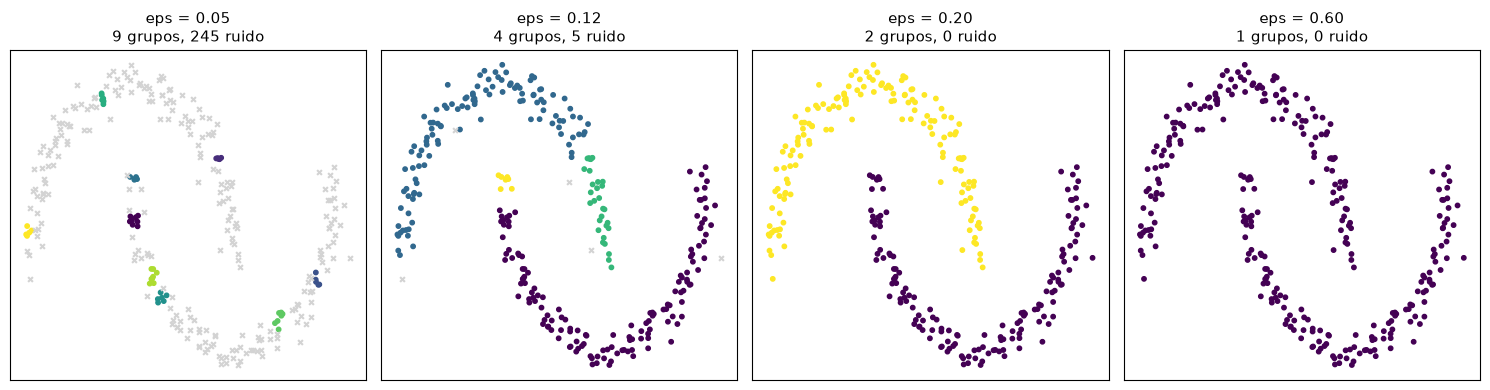

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, eps in zip(axes, [0.05, 0.12, 0.20, 0.60]):
    et = DBSCAN(eps=eps, min_samples=5).fit_predict(lunas)
    ruido = et == -1
    grupos = len(set(et)) - (1 if ruido.any() else 0)
    ax.scatter(lunas[~ruido, 0], lunas[~ruido, 1], c=et[~ruido], cmap='viridis', s=10)
    ax.scatter(lunas[ruido, 0], lunas[ruido, 1], c='lightgray', s=12, marker='x')
    ax.set_title('eps = %.2f\n%d grupos, %d ruido' % (eps, grupos, ruido.sum()), fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

El barrido es una U. Con `eps` chico casi ningún vecindario llega a 5 puntos: **245 de
300 observaciones quedan como ruido** y lo poco que sobrevive son grupitos de seis puntos. Con
`eps` grande todo queda conectado con todo y **hay un solo grupo**. La ventana buena está
en el medio, y hay que encontrarla.

La sección 5.4 muestra cómo elegirla sin adivinar.

## 4.4. Y la falla propia de DBSCAN

Hasta acá DBSCAN parece la respuesta a todo, y no lo es. `eps` es **uno solo para toda la
base**, así que si hay grupos con densidades muy distintas, ningún valor sirve para los
dos: el que capta al grupo disperso funde al denso con sus vecinos, y el que respeta al
denso declara ruido al disperso entero.



# 5. El caso: clientes de un banco

La base viene del *UCI Machine Learning Repository* y son campañas de marketing
telefónico de un banco portugués. Se armó para predecir si un cliente contrataba o no un
depósito a plazo; nosotros la vamos a usar para otra cosa: **ver si hay segmentos de
clientes ahí adentro**, sin decirle al algoritmo cuántos ni cuáles.

In [4]:
bank = pd.read_csv('data/bank_es.csv', sep=',')
print(bank.shape)
bank.head()

(4521, 17)


,edad,trabajo,estado_civil,educacion,impago,saldo,hipoteca,prestamo,contacto,día,mes,duracion,contactos_campana,dias_ultimo_contacto,contactos_previos,resultado_campana_previa,respuesta
0,30,desempleado,casado,primaria,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,servicios,casado,secundaria,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,gerente,soltero,terciaria,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,gerente,casado,terciaria,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,obrero,casado,secundaria,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## 5.1. Dos decisiones antes de iniciar

**Primera: con qué clientes.** Nos interesan los que el banco todavía no trabajó, así que
nos quedamos con los que no tuvieron ningún contacto en campañas anteriores.

**Segunda: con qué variables.** Sólo las que están disponibles para *cualquier* cliente,
incluso uno nuevo: dos numéricas (`edad`, `saldo`) y dos categóricas (`estado_civil`,
`educacion`). Nada de duración de llamada ni historial de campañas. Eso sólo existe
después de haber llamado, y un segmento que no se puede identificar de antemano no sirve
para decidir a quién llamar.

In [5]:
bank = bank[bank['contactos_previos'] == 0]

VARS = ['edad', 'saldo', 'estado_civil', 'educacion']
print('clientes sin contacto previo:', len(bank))
print(bank[VARS].dtypes.to_string())

clientes sin contacto previo: 3705
edad            int64
saldo           int64
estado_civil      str
educacion         str


## 5.2. La distancia de Gower

Un problema `edad` y `saldo` son números, `estado_civil` y `educacion` no. No hay forma de estandarizar "divorciado".

Gower (1971) lo resuelve por partes. Para cada variable calcula una **diferencia parcial**
entre 0 y 1, con una regla distinta según el tipo:

- **Numérica:** la diferencia absoluta dividida por el rango de esa variable.
  $\;\dfrac{|x_i - x_j|}{\max(x) - \min(x)}$
- **Categórica:** 1 si los valores difieren, 0 si coinciden. 

Y después promedia las $p$ diferencias parciales:

$$d_G(i,j) \;=\; \frac{1}{p}\sum_{m=1}^{p} d^{(m)}_{ij}$$

Como cada término está entre 0 y 1, el promedio también. Dos clientes idénticos dan 0.

> **Ojo con el rango.** Un valor extremo mal cargado agranda el denominador de esa
> variable y **achica todas sus diferencias parciales**, o sea que la vuelve
> irrelevante sin que nadie se entere.

Hagámoslo a mano con dos clientes de la muestra, para ver de dónde sale el número. En la
submuestra que vamos a usar, el rango de `edad` es 58 años (22 a 80) y el de `saldo` es
28 585 (de −852 a 27 733).

In [6]:
X = bank[VARS].sample(300, random_state=SEMILLA)

rango_edad  = X['edad'].max()  - X['edad'].min()
rango_saldo = X['saldo'].max() - X['saldo'].min()

a, b, c = X.iloc[0], X.iloc[1], X.iloc[2]

def parciales(u, v):
    return {'edad':         abs(u['edad'] - v['edad']) / rango_edad,
            'saldo':        abs(u['saldo'] - v['saldo']) / rango_saldo,
            'estado_civil': float(u['estado_civil'] != v['estado_civil']),
            'educacion':    float(u['educacion'] != v['educacion'])}

for nombre, u, v in [('cliente 0 vs 1', a, b), ('cliente 0 vs 2', a, c)]:
    p = parciales(u, v)
    print(nombre, {k: float(round(x, 4)) for k, x in p.items()},
          '-> Gower =', float(round(sum(p.values()) / 4, 4)))

X.head(3)

cliente 0 vs 1 {'edad': 0.2414, 'saldo': 0.0022, 'estado_civil': 0.0, 'educacion': 0.0} -> Gower = 0.0609
cliente 0 vs 2 {'edad': 0.2069, 'saldo': 0.042, 'estado_civil': 1.0, 'educacion': 1.0} -> Gower = 0.5622


,edad,saldo,estado_civil,educacion
710,46,67,casado,primaria
81,60,5,casado,primaria
4128,34,1268,divorciado,secundaria


Comparen los dos renglones. En el primer par los dos clientes coinciden en estado civil y
educación, así que **las dos categóricas aportan cero** y la distancia queda en 0,061.
Casi toda por la diferencia de edad.

En el segundo par difieren en las dos categóricas, y esas dos diferencias solas suman
2 de 4: la distancia salta a 0,562 **aunque la edad y el saldo se parezcan bastante**.

Guarden esa asimetría, porque explica todo lo que vamos a ver ahora: **una categórica que
no coincide cuesta $1/p$ entero, mientras que las numéricas aportan fracciones de
$1/p$.** En una base con muchas categóricas, las categóricas mandan.

## 5.3. La matriz de distancias

Con Gower **no hace falta inventar variables dummy ni recodificar nada**: se le pasan las
columnas como están y él se fija en el tipo de cada una. 

Trabajamos con una submuestra de 300 clientes. Y el motivo no es el cómputo. la matriz
completa se calcula en segundos, sino que **un dendrograma de 3 705 hojas es una barra
negra**. En una base de verdad el argumento sí sería el costo: $D$ crece con $n^2$, y los
45 000 clientes de la versión completa de estos datos darían una matriz de varios
gigabytes.

In [7]:
import gower
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# gower_matrix decide numerica vs categorica por el dtype de cada columna:
# las categoricas tienen que llegar como texto, NO como dummies.
# El astype(object) es defensivo: pandas 3 lee el texto como StringDtype,
# que gower todavia no reconoce.
X_gower = X.astype({'estado_civil': object, 'educacion': object})

D = gower.gower_matrix(X_gower).astype(np.float64)

print('forma:', D.shape)
print('rango: %.3f a %.3f' % (D.min(), D.max()))
print('simetrica:', np.allclose(D, D.T), '| diagonal en cero:', np.allclose(np.diag(D), 0))

forma: (300, 300)
rango: 0.000 a 0.873
simetrica: True | diagonal en cero: True


## 5.4. Clustering jerárquico sobre esa matriz

`linkage` no recibe la matriz cuadrada sino su forma condensada (la mitad de arriba, sin
la diagonal). Y usamos enlace **promedio**: Ward está fuera de discusión acá, porque esto
no es una distancia euclidiana.

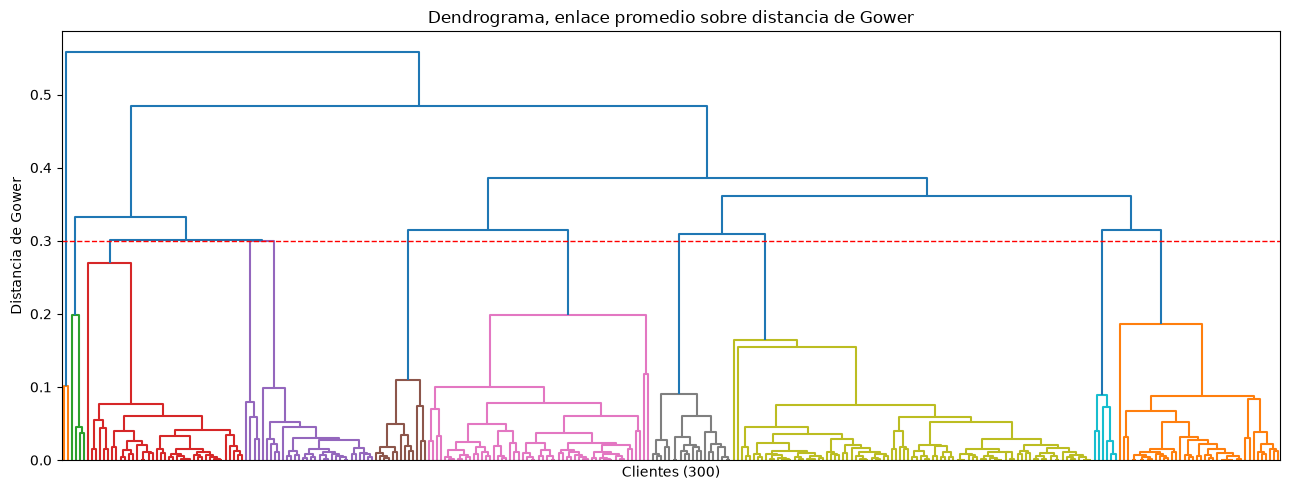

altura maxima del arbol: 0.559


In [8]:
D_condensada = squareform(D, checks=False)
Z = linkage(D_condensada, method='average')

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, no_labels=True, color_threshold=0.30, ax=ax)
ax.axhline(y=0.30, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Clientes (300)')
ax.set_ylabel('Distancia de Gower')
ax.set_title('Dendrograma, enlace promedio sobre distancia de Gower')
plt.tight_layout(); plt.show()

print('altura maxima del arbol: %.3f' % Z[:, 2].max())

Fíjense en el eje vertical: **el árbol entero mide menos de 0,6**. 
La línea roja corta en 0,30. Veamos qué queda.

In [9]:
corte = fcluster(Z, t=0.30, criterion='distance')
print('ramas a la altura 0.30:', corte.max())
print(pd.Series(corte).value_counts().sort_values(ascending=False).to_string())

ramas a la altura 0.30: 10
8     89
6     55
10    40
3     39
4     32
7     20
5     13
9      6
2      4
1      2


Diez ramas. Pero tres de ellas tienen 6, 4 y 2 clientes. Las **siete** que quedan son
grupos de verdad, de 13 clientes para arriba.

`fcluster` también acepta pedir directamente un número de grupos en vez de una altura, así
que nos quedamos con esos siete:

In [10]:
jerarquico = pd.Series(fcluster(Z, t=7, criterion='maxclust'), index=X.index, name='rama')
pd.crosstab([X['estado_civil'], X['educacion']], jerarquico)

rama                      1  2   3   4   5   6   7
estado_civil educacion                            
casado       desconocido  0  0   0   0   0   0   6
             primaria     0  0   0   0   0   0  40
             secundaria   0  0   0   0   0  89   0
             terciaria    0  0   0   0  55   0   0
divorciado   primaria     2  0   0   0   0   0   0
             secundaria   0  0   0   0   0  20   0
             terciaria    0  0   0  13   0   0   0
soltero      desconocido  0  0   4   0   0   0   0
             primaria     0  4   0   0   0   0   0
             secundaria   0  0  28   0   0   0   0
             terciaria    0  0  39   0   0   0   0

Miremos la tabla, cuatro ramas son una casilla exacta. Las otras tres son fusiones: una se queda con
**todos los solteros** (71, sin importar la educación), otra junta a los dos grupos de
**secundaria** (109, casados y divorciados), y otra a los casados de primaria con los
casados sin educación reportada (46).

En ningún lado aparece un grupo del estilo "los jóvenes con saldo alto". 

## 5.5. DBSCAN sobre la misma matriz

Acá está la ventaja de haber construido $D$ aparte: **el mismo insumo, otro algoritmo**.
No hay que preguntarse si la comparación es justa, porque la distancia no cambió.

Primero elegimos `eps` con el gráfico de $k$-distancia. La receta: para cada punto se mide
la distancia a su $k$-ésimo vecino, se ordenan de menor a mayor, y se busca el codo. Y el
$k$ del gráfico **tiene que ser el mismo `min_samples` que después le pasamos al modelo**.

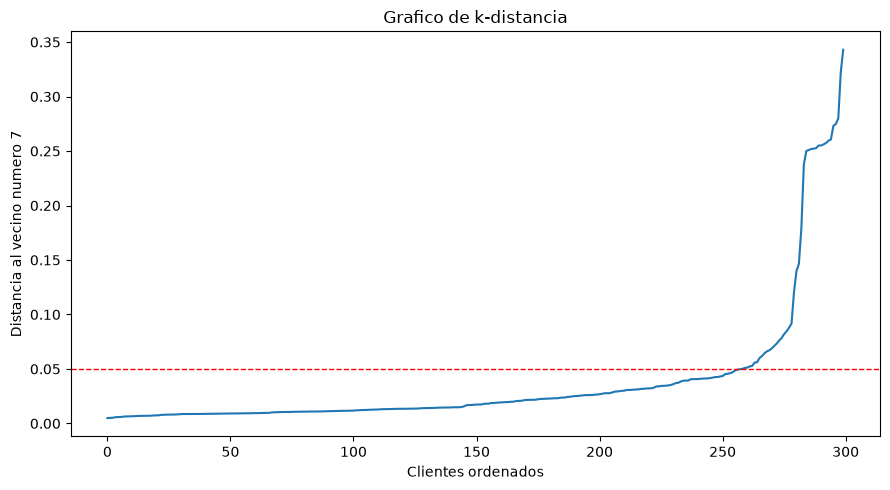

percentiles de la k-distancia: [0.011 0.017 0.034 0.067 0.25 ]


In [11]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 7

vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='precomputed').fit(D)
distancias, _ = vecinos.kneighbors(D)
k_dist = np.sort(distancias[:, -1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_dist)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Clientes ordenados')
ax.set_ylabel('Distancia al vecino numero %d' % MIN_SAMPLES)
ax.set_title('Grafico de k-distancia')
plt.tight_layout(); plt.show()

print('percentiles de la k-distancia:',
      np.percentile(k_dist, [25, 50, 75, 90, 95]).round(3))

La curva va plana y en el último 10 % se dispara. Ese quiebre es el codo, y cae alrededor
de **0,05**: por debajo estamos dentro de las zonas densas, por encima ya estamos midiendo
contra puntos que no tienen con quién juntarse.

No hay que ser quirúrgico. Es una sugerencia, no un teorema, de hecho cualquier valor
entre 0,04 y 0,22 da los mismos siete grupos acá; lo que cambia es cuántos puntos quedan
como ruido.

In [12]:
EPS = 0.05

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='precomputed').fit_predict(D)

X = X.copy()
X['cluster'] = db

n_grupos = len(set(db)) - (1 if -1 in db else 0)
n_ruido  = (db == -1).sum()
print('grupos: %d | ruido: %d clientes (%.1f%%)' % (n_grupos, n_ruido, 100 * n_ruido / len(X)))

grupos: 7 | ruido: 29 clientes (9.7%)


In [13]:
pd.crosstab([X['estado_civil'], X['educacion']], X['cluster'])

cluster                   -1   0   1   2   3   4   5   6
estado_civil educacion                                  
casado       desconocido   6   0   0   0   0   0   0   0
             primaria      2  38   0   0   0   0   0   0
             secundaria    2   0   0  87   0   0   0   0
             terciaria     4   0   0   0   0   0  51   0
divorciado   primaria      2   0   0   0   0   0   0   0
             secundaria    0   0  20   0   0   0   0   0
             terciaria     3   0   0   0   0   0   0  10
soltero      desconocido   4   0   0   0   0   0   0   0
             primaria      4   0   0   0   0   0   0   0
             secundaria    1   0   0   0   0  27   0   0
             terciaria     1   0   0   0  38   0   0   0

Lo mismo, y esta vez sin las tres fusiones: **cada grupo es una casilla del cruce, uno a
uno**. Casados con secundaria, casados con terciaria, casados con primaria, solteros con
terciaria, solteros con secundaria, divorciados con secundaria, divorciados con terciaria.

Dos algoritmos que no se parecen en nada, un solo insumo, y el mismo resultado. Cuando eso
pasa, el resultado no lo está poniendo el algoritmo: lo está poniendo la distancia.

 Cada categórica que no coincide
cuesta 0,25, y `eps` vale 0,05: **dos clientes que difieren en una sola categórica nunca
pueden ser vecinos**, por parecidos que sean en edad y saldo. Las numéricas quedaron de
adorno.

> El clustering no descubrió segmentos. Descubrió la tabla de contingencia de las dos
> variables categóricas que nosotros elegimos meter.
>
> Es la misma lección de la semana pasada: un clustering no descubre la verdad, descubre
> la estructura que tienen las variables que uno decidió medir.

## 5.6. Lo que ninguno de los dos podía dar antes

Los grupos resultaron ser una tabla cruzada. Lo interesante está en la otra columna: los
**29 clientes que DBSCAN no puso en ningún grupo**.

In [14]:
ruido = X[X['cluster'] == -1]

print('ruido: %d clientes de %d (%.1f%%)' % (len(ruido), len(X), 100 * len(ruido) / len(X)))
print()
print('saldo mediano  -- ruido: %7.0f | muestra completa: %7.0f'
      % (ruido['saldo'].median(), X['saldo'].median()))
print('edad           -- ruido: de %d a %d anios' % (ruido['edad'].min(), ruido['edad'].max()))
print()
p95 = np.percentile(X['saldo'], 95)
print('saldos del ruido por encima del percentil 95 de la muestra (%.0f):' % p95)
print(sorted(ruido.loc[ruido['saldo'] > p95, 'saldo'].tolist()))

ruido: 29 clientes de 300 (9.7%)

saldo mediano  -- ruido:    2443 | muestra completa:     342
edad           -- ruido: de 24 a 80 anios

saldos del ruido por encima del percentil 95 de la muestra (6180):
[6483, 7337, 7708, 7727, 7813, 9009, 9149, 9676, 11262, 14363, 21664, 27733]


In [15]:
print('educacion de los 29 del ruido:')
print(ruido['educacion'].value_counts().to_string())
print()
print("clientes con educacion 'desconocido' en la muestra: %d"
      % (X['educacion'] == 'desconocido').sum())
print("de esos, cuantos quedaron como ruido:              %d"
      % (ruido['educacion'] == 'desconocido').sum())

educacion de los 29 del ruido:
educacion
desconocido    10
terciaria       8
primaria        8
secundaria      3

clientes con educacion 'desconocido' en la muestra: 10
de esos, cuantos quedaron como ruido:              10


Dos hallazgos, en la misma lista de 29 nombres:

**Uno comercial.** El saldo mediano del ruido es siete veces el de la muestra, y doce de
los veintinueve están por encima del percentil 95 — hasta un cliente con 27 733. Son los
clientes más ricos del banco, y son "raros" precisamente por eso: no hay otros como
ellos con quienes agruparse. En una campaña de marketing, ésa es la lista que uno quiere.

**Uno de calidad de datos.** Los diez clientes cuyo nivel educativo figura como
*desconocido* están **los diez** en el ruido. Sin excepción. La categoría es tan chica que
ninguno llega a juntar siete vecinos, así que el algoritmo los expulsa a todos. No
descubrió nada sobre esas personas: descubrió que el formulario faltaban datos, estaba incompleto.

> Y ésta es la respuesta a la pregunta con la que abrimos. Ni K-medias ni el jerárquico
> podían señalar a estos 29, porque los dos obligan a que **todo** punto pertenezca a
> algún grupo. Los habrían repartido entre los siete, contaminando cada uno un poco, y
> nadie se habría enterado.

# 6. Para cerrar

Volviendo al inicio

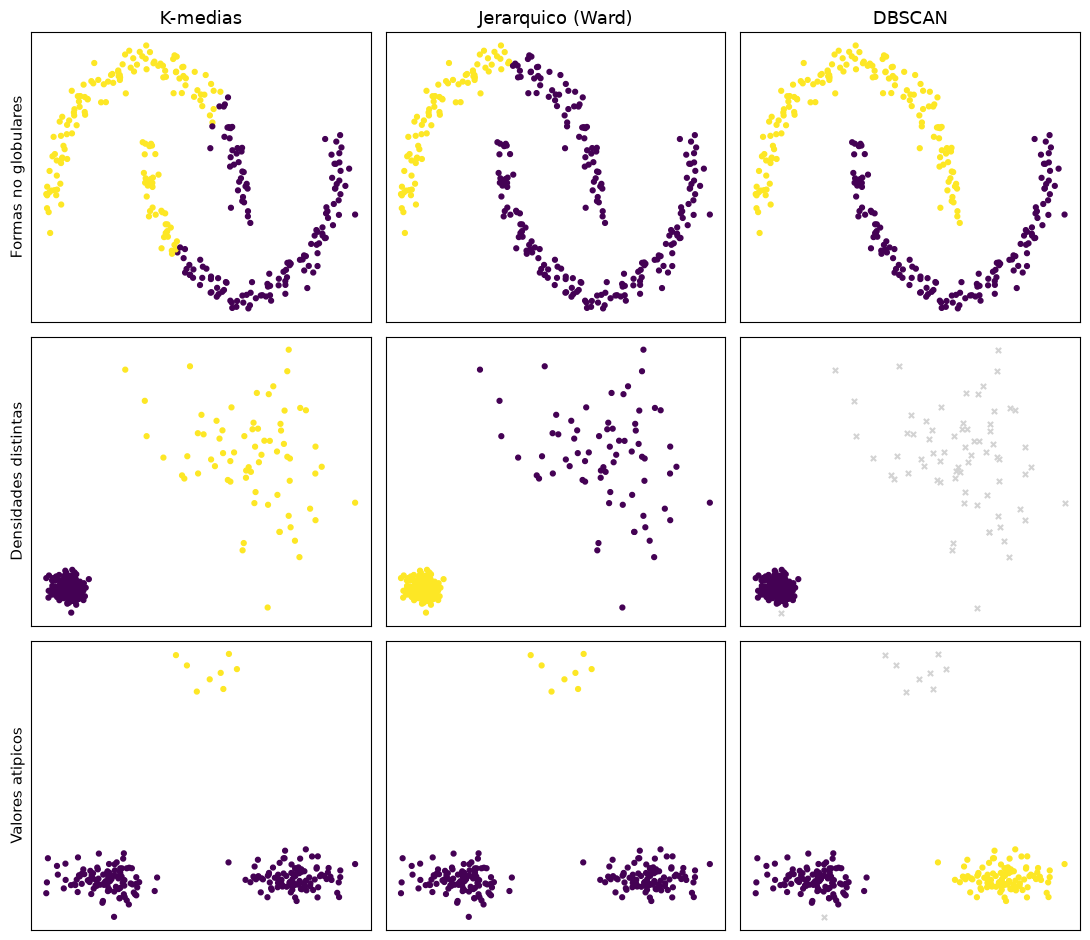

In [16]:
grilla(SITUACIONES, columnas_visibles=3)


- **Formas no esfericas.** Los dos primeros parten las lunas por el medio, cada uno a su
  manera. DBSCAN las separa sin esfuerzo, porque nunca preguntó por la forma.
- **Densidades distintas.** Los dos primeros aciertan, y **DBSCAN
  declara ruido al grupo disperso entero**. Un solo `eps` no puede servir para dos
  densidades.
- **Valores atípicos.** Ocho puntos se llevan un centroide y funden los dos grupos reales,
  y a Ward le pasa lo mismo. DBSCAN es el único que los aparta y deja los dos grupos en pie.

> Ninguna columna está limpia. Elegir algoritmo no es elegir el mejor: es saber en qué
> falla el que uno eligió, y si esa falla importa en el problema que uno tiene.

## El *caveat*

Los métodos de clustering son exploratorios. Pero no importa lo que entre al algoritmo:
los clusters salen igual. Es la situación clásica de "basura que entra, basura que sale".

Hoy lo vimos en vivo y sin necesidad de basura: metimos cuatro variables razonables, el
algoritmo corrió sin errores, devolvió siete grupos limpios y bien separados... **y esos
siete grupos eran una tabla de contingencia**. Ninguna medida de validez interna nos
habría avisado.

La agrupación es buena si sirve para responder el problema. Eso no lo decide el
algoritmo.

# Referencias

- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). A density-based algorithm for
  discovering clusters in large spatial databases with noise. *KDD-96*, 226–231.
- Gower, J. C. (1971). A general coefficient of similarity and some of its properties.
  *Biometrics*, 27(4), 857–871.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to
  Statistical Learning* (2ª ed.), cap. 12. Springer.
- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). *Mining of Massive Datasets*.
  Cambridge University Press.
- Sokal, R. R., & Michener, C. D. (1958). A statistical method for evaluating systematic
  relationships. *University of Kansas Science Bulletin*, 38, 1409–1438.
- Sheehan, D. (2022). *Clustering with Scikit with GIFs* —
  https://dashee87.github.io/data%20science/general/Clustering-with-Scikit-with-GIFs/
  (de ahí salen las figuras de la sección 4.2).
- Waggoner, P. *Unsupervised Machine Learning for Clustering in Political and Social
  Research*. Mimeo.
- Datos: *Bank Marketing Data Set*, UCI Machine Learning Repository.

# Información de Sesión

In [17]:
try:
    import session_info
    session_info.show(html=False)
except ImportError:
    # Respaldo por si session_info no esta instalado (p. ej. en Coursera)
    import sys
    import numpy, pandas, scipy, sklearn, matplotlib, seaborn, gower
    print("python     ", sys.version.split()[0])
    for nombre, modulo in [("numpy", numpy), ("pandas", pandas), ("scipy", scipy),
                           ("scikit-learn", sklearn), ("matplotlib", matplotlib),
                           ("seaborn", seaborn), ("gower", gower)]:
        print("%-14s %s" % (nombre, getattr(modulo, "__version__", "?")))

-----
gower               NA
matplotlib          3.11.1
numpy               2.4.6
pandas              3.0.5
scipy               1.17.1
session_info        v1.0.1
sklearn             1.9.0
-----
IPython             9.16.1
jupyter_client      8.9.1
jupyter_core        5.9.1
jupyterlab          4.6.3
notebook            7.6.2
-----
Python 3.11.16 | packaged by conda-forge | (main, Aug 21 2026, 22:58:50) [Clang 19.1.7 ]
macOS-26.5.2-x86_64-i386-64bit
-----
Session information updated at 2026-08-24 17:09
